# **MODEL ORDER REDUCTION AND MACHINE LEARNING - Project**
**A.Y. 2025/2026**
## Francabandiera Riccardo (s345950), Morandi Simone Domenico (s336974), Pautasso Elisabetta (s337091)

### POD-Galerkin on parametric Navier-Stokes equations.

# Defining the problem

In [1]:
# Basic imports.
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
import time
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

In [2]:
# Mesh utilities.
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

## Original problem

Solve the Navier-Stokes equation on square ${\Omega} = (0, 1)^2$

$$
\begin{cases}
-\mu_0 \nabla \cdot (\nabla \mathbf{u}) + (\nabla \mathbf{u})\mathbf{u} + \nabla p = \mathbf{f}(x;\mu_1) & \text{in } \Omega\\
(\nabla \cdot \mathbf{u}) = 0 & \text{in } \Omega\\
u = 0 & \text{in } ∂ \Omega
\end{cases}
$$

where:

$\quad u=u(\vec{\mu})$

$\quad \vec{\mu} = (\mu_0,\mu_1)$

$\quad \mu_0 \in [0.1,10]$

$\quad \mu_1 \in [1.0,3.0]$

$\quad f(x;\mu_1) = -((µ^3_1 π^2\cos(µ^2_1πx)−µ^2_1π^2)\sin(µ_1πy)\cos(µ_1πy)+(µ_1π\cos(µ_1πx)\cos(µ_1πy))$



In order to have a unique solution, we fix $p=0$ in $(0.0,0.0)$.

### Discretization

In [3]:
# Defining the square.
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [4]:
# Defining mesh type and quality.
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001

In [5]:
# Generating mesh.
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

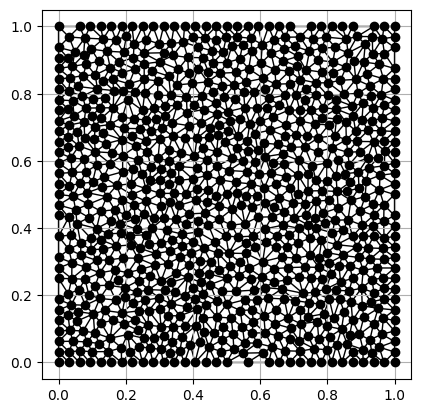

In [6]:
# Exporting and visualizing mesh.
vtk_utilities.export_mesh("./Export", mesh)
export_solution_path = "./Export/Solution" # Fixing solution path for later.
other_ut.plot_mesh(mesh)

# High fidelity approximation
We fix a value of $\vec{\mu}$ and solve the N-S equations using Newton's method.

The first thing to do is setting the boundary condition for the initial problem.

In [7]:
# Defining border info.
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

# p=0 on all borders.
pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

# u=v=0 on all borders.
speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

Now we create the Taylor-Hood finite element, since it is sup-inf stable and can be used to solve N-S numerically.

In [8]:
# Creating Taylor-Hood finite element.
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [9]:
# Defining dofs.
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs
print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


Now we fix $\vec{\mu}$ and define the operators for the forcing term, the pressure and the velocity.

In [10]:
# Defining a fixed mu value.
mu_fixed = [5.0,3.0]

In [11]:
# Defining source term functions and their operators.
def f_x_function(x, y, z, mu):
    term1 = -(mu[1]**3 * np.pi**2 * np.cos(mu[1]**2 * np.pi * x) \
              - mu[1]**2 * np.pi**2) \
             * np.sin(mu[1] * np.pi * y) * np.cos(mu[1] * np.pi * y)
    term2 = mu[1] * np.pi * np.cos(mu[1] * np.pi * x) * np.cos(mu[1] * np.pi * y)
    return term1 + term2

def f_y_function(x, y, z):
    return np.zeros_like(x)

f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu_fixed))
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

In [12]:
# Defining pressure function and its operator.
def pressure_strong_function(marker, x, y, z):
    return np.zeros_like(x)

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)

In [13]:
# Defining speed functions and their operators.
def speed_x_strong_function(marker, x, y, z):
    return np.zeros_like(x)

def speed_y_strong_function(marker, x, y, z):
    return np.zeros_like(x)

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_y_strong_function)

In [14]:
# Defining matrices.
def mu_0_term(x, y, z, mu):  
    return mu[0]
def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])

A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                        lambda x,y,z: mu_0_term(x,y,z,mu_fixed))


J_A_x = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
J_A_y = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

In [15]:
# Defining vectors of the numerical solution.
def speed_x_initial_condition(x, y, z):  
    return 0.0
def speed_y_initial_condition(x, y, z):  
    return 0.0
def pressure_initial_condition(x, y, z):  
    return 0.0

u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_x_initial_condition).function_dofs
u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_y_initial_condition).function_dofs
p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                pressure_initial_condition).function_dofs

u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
du_x_strong = np.zeros(speed_n_strongs)
du_y_strong = np.zeros(speed_n_strongs)
dp_strong = np.zeros(pressure_n_strongs)

## Newton's Method

We now solve the N-S discretized equation using Newton's method.

In [16]:
# Initializing
residual_norm = 1.0
newton_tol = 1.0e-6
max_iterations = 10
num_iteration = 1
# While loop.
while num_iteration < max_iterations and residual_norm > newton_tol: 
    # (nabla u)u discrete term.
    c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     u_x_numeric,
                                                                                     u_y_numeric,
                                                                                     u_x_strong,
                                                                                     u_y_strong)
    
    J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])

    J_f = f_S - f_C - J_S @ u_k
    du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)
    
    u_k = u_k + du

    du_x = du[0:speed_n_dofs]
    du_y = du[speed_n_dofs:2 * speed_n_dofs]
    dp = du[2 * speed_n_dofs:]

    u_x_numeric = u_k[0:speed_n_dofs]
    u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
    p_numeric = u_k[2 * speed_n_dofs:]

    du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
    du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_y,
                                                                                 du_y_strong)
    dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 pressure_dofs_data,
                                                                                 pressure_reference_element_data,
                                                                                 dp,
                                                                                 dp_strong)

    residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                           du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                           dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);

    print("dofs", "residual", "iteration", "max_iteration")
    print(tot_dofs, '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
    num_iteration = num_iteration + 1

dofs residual iteration max_iteration
6761 6.1443111278492797e+00 1 10
dofs residual iteration max_iteration
6761 2.6904277610200925e-04 2 10
dofs residual iteration max_iteration
6761 1.5858690509775123e-12 3 10


In order to better understand the result of Newton's method, we plot the solution.

In [17]:
u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_x_numeric,
                                                                                         u_x_strong,
                                                                       )
u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_y_numeric,
                                                                                         u_y_strong,
                                                                       )
p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         p_numeric,
                                                                                         p_strong,
                                                                       )

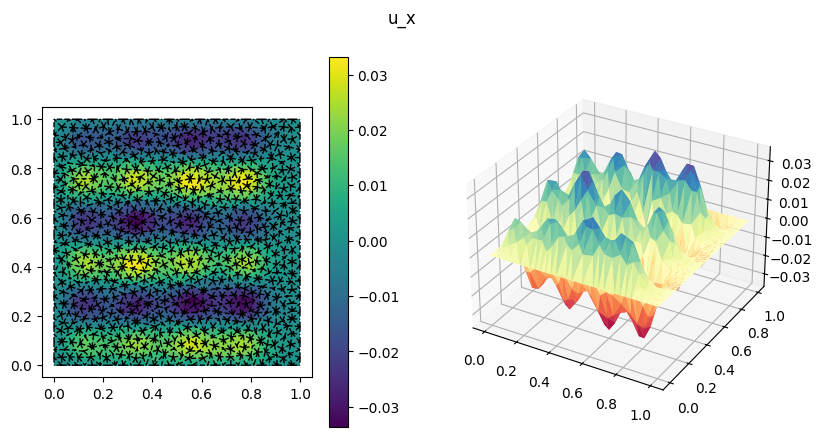

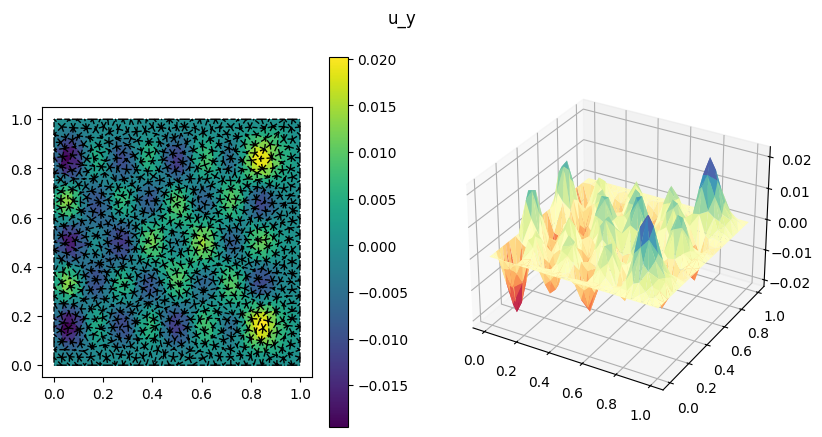

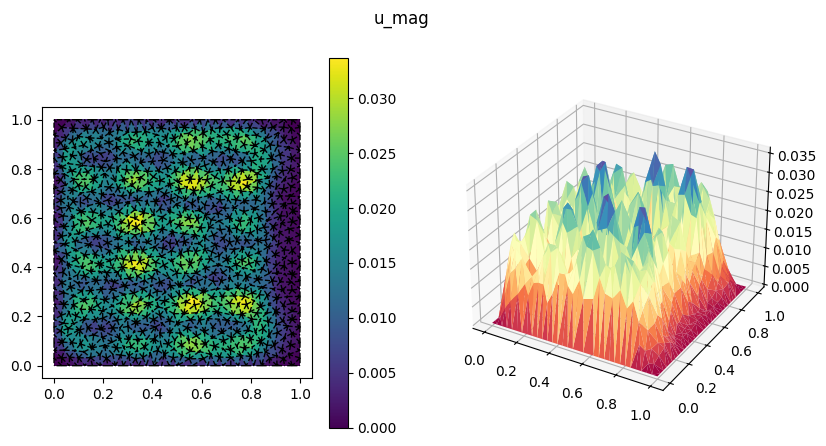

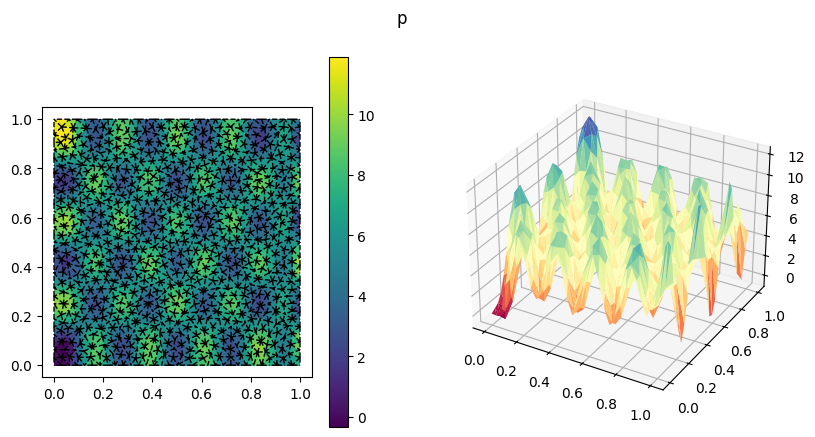

In [18]:
# Exporting and plotting the numerical solution.
other_ut.plot_solution(mesh, u_x_on_cell0Ds.numeric_solution, "u_x") 
other_ut.plot_solution(mesh, u_y_on_cell0Ds.numeric_solution, "u_y")
other_ut.plot_solution(mesh, np.sqrt(u_x_on_cell0Ds.numeric_solution * u_x_on_cell0Ds.numeric_solution + u_y_on_cell0Ds.numeric_solution * u_y_on_cell0Ds.numeric_solution), "u_mag")
other_ut.plot_solution(mesh, p_on_cell0Ds.numeric_solution, "p") 

We were able to solve the N-S equations numerically for a fixed value of $\vec{\mu}$. As one could expect, changing the value of $mu_0$ will change the values of the solution, while changing the value of $\mu_1$ modifies the number of oscillations of all the solution's components.

Now we can proceed with the POD. 

# Offline Phase for POD

The first thing we need for POD is the snapshot matrix. We start with defining some utilities matrices and thhe training set.

In [19]:
# Defining training set.
snapshot_num = 100
mu0_range = [0.1, 10.0]
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

np.random.seed(0)
training_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_num, P.shape[0]))

In [20]:
# Defining utilities matrices.
X_1 = other_ut.make_np_sparse(A_operator.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [0, 0])
X_2 = other_ut.make_np_sparse(A_operator.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [speed_n_dofs, speed_n_dofs])
B_1 = other_ut.make_np_sparse(B_x_operator.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, 0])
B_2 = other_ut.make_np_sparse(B_y_operator.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, speed_n_dofs])

We define a function that applies Newton's method to solve N-S, given a value of $\vec{\mu}$, since we are going to solve multiple N-S problems.

In [21]:
def solve_ns(mu):
    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu))
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_reference_element_data,
                                                                           f_y_function)
    
    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)
    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function)
    A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                       lambda x,y,z: mu_0_term(x,y,z,mu))


    J_A_x = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    J_A_y = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])
    
    B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           pressure_dofs_data,
                                                                           speed_reference_element_data,
                                                                           pressure_reference_element_data,
                                                                           b_x_term)
    B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           pressure_dofs_data,
                                                                           speed_reference_element_data,
                                                                           pressure_reference_element_data,
                                                                           b_y_term)
    
    J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
    J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
    J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
    J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)
    
    
    J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y
    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_x_initial_condition).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_y_initial_condition).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    pressure_initial_condition).function_dofs
    
    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)

    # Newtons' Method.
    residual_norm = 1.0
    solution_norm = 1.0
    newton_tol = 1.0e-6
    max_iterations = 10
    num_iteration = 1
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm: 
        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(geometry_utilities,
                                                                                         mesh,
                                                                                         mesh_geometric_data,
                                                                                         speed_dofs_data,
                                                                                         speed_reference_element_data,
                                                                                         u_x_numeric,
                                                                                         u_y_numeric,
                                                                                         u_x_strong,
                                                                                         u_y_strong)
        
        J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])
    
        J_f = f_S - f_C - J_S @ u_k
        du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)
        
        u_k = u_k + du
    
        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2 * speed_n_dofs]
        dp = du[2 * speed_n_dofs:]
    
        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_k[2 * speed_n_dofs:]

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                         mesh,
                                                                                         mesh_geometric_data,
                                                                                         speed_dofs_data,
                                                                                         speed_reference_element_data,
                                                                                         du_x,
                                                                                         du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)
        
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                           du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                           dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);
        
        print("dofs", "residual", "iteration", "max_iteration")
        print(tot_dofs, '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
        num_iteration = num_iteration + 1
    return u_k

Now we can compute the snapshot matrix, along with the supremizer one.

In [22]:
# Assembling the snaphot matrix.
snapshot_matrix_u = []
snapshot_matrix_s = [] # Supremizer snapshot.
snapshot_matrix_p = []

# Initializing
tol = 1. - 1e-7
N_max = 20

print("Performing training...")
it = 0
for mu in training_set:
    if it % 10 == 0:
      print("\tIterations", 2 * it, " /", training_set.size)
    it = it + 1
    
    snapshot_solution = solve_ns(mu)
    snapshot_u = snapshot_solution[0:2 * speed_n_dofs]
    snapshot_matrix_u.append(np.copy(snapshot_u))
    
    snapshot_p = snapshot_solution[2 * speed_n_dofs:]
    snapshot_matrix_p.append(np.copy(snapshot_p))
    
    snapshot_s = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ snapshot_p)
    snapshot_matrix_s.append(np.copy(snapshot_s)) 

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)  

print("Training performed")

Performing training...
	Iterations 0  / 200
[5.53325369 2.43037873]
dofs residual iteration max_iteration
6761 4.6628787554637858e+00 1 10
dofs residual iteration max_iteration
6761 2.1832083757753769e-04 2 10
dofs residual iteration max_iteration
6761 6.6352576297990650e-13 3 10
[6.06735742 2.08976637]
dofs residual iteration max_iteration
6761 3.6901129776097505e+00 1 10
dofs residual iteration max_iteration
6761 2.0314840425618178e-04 2 10
dofs residual iteration max_iteration
6761 3.4736052146880973e-13 3 10
[4.29418251 2.29178823]
dofs residual iteration max_iteration
6761 4.2561687380555098e+00 1 10
dofs residual iteration max_iteration
6761 3.6714457057309509e-04 2 10
dofs residual iteration max_iteration
6761 1.3414002427240586e-12 3 10
[4.43211339 2.783546  ]
dofs residual iteration max_iteration
6761 5.6574572081634553e+00 1 10
dofs residual iteration max_iteration
6761 3.3177506068827442e-04 2 10
dofs residual iteration max_iteration
6761 1.4028161665465466e-12 3 10
[9.64026

Now we retrieve the eigenvalues and eigenvector to retrieve the energy from the covariance matrix.

In [23]:
# Defining inner product of X matrices for eigenvalues analysis.
inner_product_u = X_1 + X_2

In [24]:
# Function that returns the dimension and the eigenvalue of the Covariance matrix.
def eig_analysis(C, N_max=None, tol=1e-9):
  L_e, VM_e = np.linalg.eig(C)
  eigenvalues = []
  eigenvectors = []

  for i in range(len(L_e)):
    eig_real = L_e[i].real
    eig_complex = L_e[i].imag
    assert np.isclose(eig_complex, 0.)
    eigenvalues.append(eig_real)
    eigenvectors.append(VM_e[i].real)


  total_energy = sum(eigenvalues)
  retained_energy_vector = np.cumsum(eigenvalues)
  relative_retained_energy = retained_energy_vector/total_energy


  if all(flag==False for flag in relative_retained_energy>= tol) and N_max != None:
    N = N_max
  else:
    N = np.argmax(relative_retained_energy >= tol) + 1
  
  return N, eigenvectors

In [25]:
# Assembling covariance matrix from snapshot matrices.
C_u = snapshot_matrix_u @ inner_product_u @ np.transpose(snapshot_matrix_u)
C_s = snapshot_matrix_s @ inner_product_u @ np.transpose(snapshot_matrix_s)
C_p = snapshot_matrix_p @ np.transpose(snapshot_matrix_p)

N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)

print(N_u, N_s, N_p)

19 24 20


We can now create the basis functions and the reduced system.

In [26]:
# Function that creates basis functions from snapshots and eigenvectors of the covariance matrix.
def create_basis_functions_matrix(N, snapshot_matrix, eigenvectors, inner_product=None):
  
  basis_functions = []
  
  for n in range(N):
    eigenvector =  eigenvectors[n]
    basis = np.transpose(snapshot_matrix)@eigenvector
    if inner_product!= None:
      norm = np.sqrt(np.transpose(basis) @ inner_product @ basis)
    else:
      norm = np.sqrt(np.transpose(basis) @ basis)
    basis /= norm
    basis_functions.append(np.copy(basis))

  basis_function_matrix = np.transpose(np.array(basis_functions))
  
  return basis_function_matrix

In [27]:
# Creating basis functions.
basis_functions_u = create_basis_functions_matrix(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
basis_functions_s = create_basis_functions_matrix(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
basis_functions_p = create_basis_functions_matrix(N_p, snapshot_matrix_p, eigs_p)

In [28]:
print(basis_functions_u.shape)
print(basis_functions_p.shape)
print(basis_functions_u.shape[0] + basis_functions_p.shape[0])
print(basis_functions_p.shape)

global_basis_function_matrix = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
global_basis_function_matrix[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix[0:basis_functions_u.shape[0], N_u : N_u + N_s] = basis_functions_s
global_basis_function_matrix[basis_functions_u.shape[0]:, N_u + N_s:] = basis_functions_p
print(global_basis_function_matrix.shape)

global_basis_function_matrix_no_sup = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_p))
global_basis_function_matrix_no_sup[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix_no_sup[basis_functions_u.shape[0]:, N_u:] = basis_functions_p

(5932, 19)
(829, 20)
6761
(829, 20)
(6761, 63)


In [29]:
# Function that assembles reduced matrix.
def assemble_reduced_matrix(basis, fom_matrix):
  return np.transpose(basis) @ (fom_matrix) @ basis

# Function that asse,bles reduced vector.
def assemble_reduced_vector(basis, fom_vector):
  return np.transpose(basis) @ (fom_vector)

In [30]:
# Assembling reduced system.
reduced_stiff_Stokes = assemble_reduced_matrix(global_basis_function_matrix, (J_A_x + J_A_y)) 
reduced_divergence_operator_1 = assemble_reduced_matrix(global_basis_function_matrix, (J_BT_x)) 
reduced_divergence_operator_2 = assemble_reduced_matrix(global_basis_function_matrix, (J_BT_y))

# Online Phase for POD 

Our model is now ready to compute the solution for the N-S equation given a new value of $\vec{\mu}$.

In [31]:
# Fixing a new value of mu and solving the system.
mu_new = [2.0,1.5]

# Updating f_x and f_y since they depend on mu
f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu_new))
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                   mesh,
                                                                   mesh_geometric_data,
                                                                   speed_dofs_data,
                                                                   speed_reference_element_data,
                                                                   speed_reference_element_data,
                                                                   f_y_function)

J_f = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

# Updating with mu_0.
reduced_lhs = mu[0]*reduced_stiff_Stokes - reduced_divergence_operator_1 - reduced_divergence_operator_2 - np.transpose(reduced_divergence_operator_1) - np.transpose(reduced_divergence_operator_2)
reduced_rhs = assemble_reduced_vector(global_basis_function_matrix, J_f)

In [32]:
# Solving with the reduced system.
reduced_solution = np.linalg.solve(reduced_lhs, reduced_rhs)

In order to see whether the results are plausible, we plot again the solution.

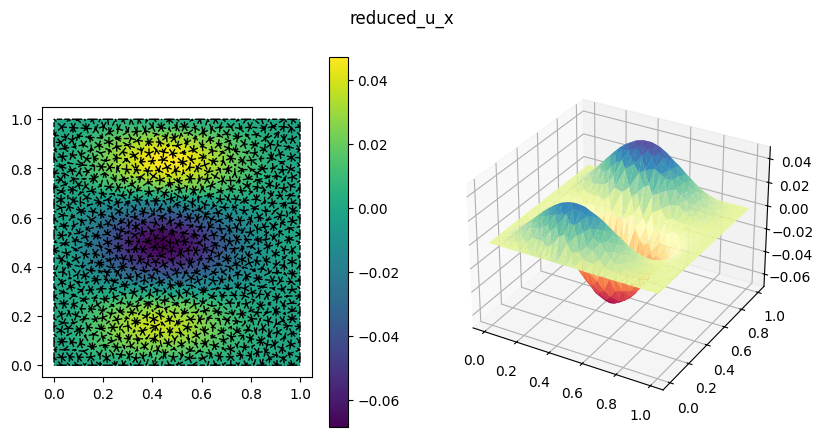

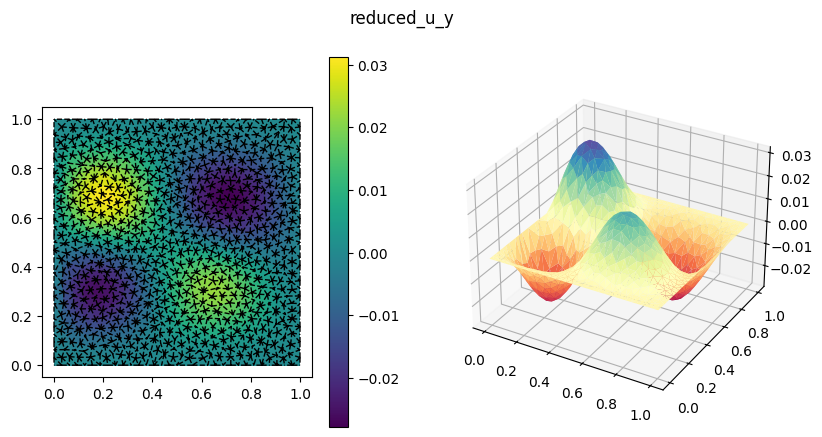

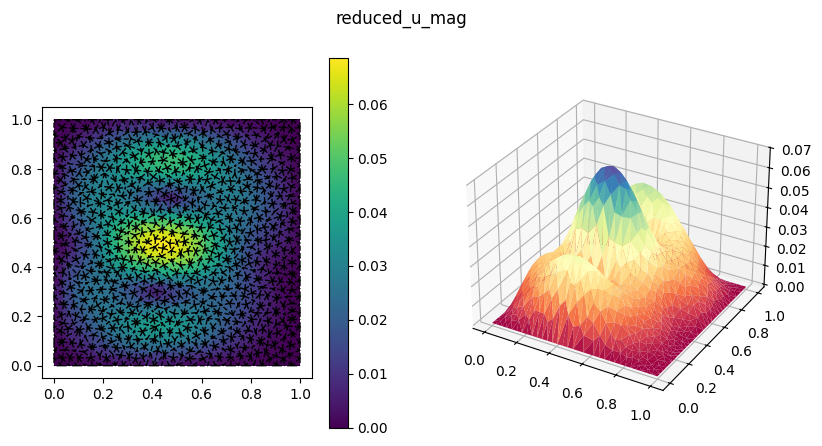

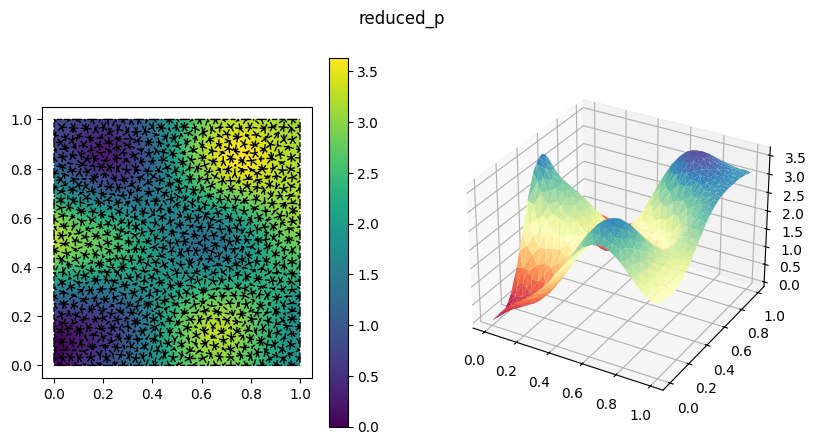

In [33]:
# Plotting the solution.
reduced_u_dof = N_u + N_s
reduced_p_dof = N_p
reduced_solution_FE_basis = global_basis_function_matrix @ reduced_solution
reduced_u_x = reduced_solution_FE_basis[0:speed_n_dofs]
reduced_u_y = reduced_solution_FE_basis[speed_n_dofs:2 * speed_n_dofs]
reduced_p = reduced_solution_FE_basis[2 * speed_n_dofs:]

reduced_u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         reduced_u_x,
                                                                                         u_x_strong,
                                                                       )
reduced_u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         reduced_u_y,
                                                                                         u_y_strong,
                                                                       )
reduced_p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         reduced_p,
                                                                                         p_strong,
                                                                       )

vtk_utilities.export_solution_2(export_solution_path + '/reduced_u_x',
                                mesh, 
                                reduced_u_x_on_cell0Ds.numeric_solution)
vtk_utilities.export_solution_2(export_solution_path + '/reduced_u_y',
                                mesh, 
                                reduced_u_y_on_cell0Ds.numeric_solution)
vtk_utilities.export_solution_2(export_solution_path + '/reduced_p',
                                mesh, 
                                reduced_p_on_cell0Ds.numeric_solution)
other_ut.plot_solution(mesh, reduced_u_x_on_cell0Ds.numeric_solution, "reduced_u_x") 
other_ut.plot_solution(mesh, reduced_u_y_on_cell0Ds.numeric_solution, "reduced_u_y")
other_ut.plot_solution(mesh, np.sqrt(reduced_u_x_on_cell0Ds.numeric_solution * reduced_u_x_on_cell0Ds.numeric_solution + reduced_u_y_on_cell0Ds.numeric_solution * reduced_u_y_on_cell0Ds.numeric_solution), "reduced_u_mag")
other_ut.plot_solution(mesh, reduced_p_on_cell0Ds.numeric_solution, "reduced_p") 

One can see that if $\mu_{\text{new}} =\mu_{\text{fixed}}$, the plots are almost identical. 

We can see this numerically by computing the error between the FOM model and the ROM model.

In [34]:
# Function that computes the error between the FOM solution and the POD solution.
def compute_error(fom_solution, rom_solution_FE_basis, inner_product=None, type_err="relative"):
    
    error_function_u = fom_solution - rom_solution_FE_basis
    
    if inner_product == None:
        inner_product_matrix = np.identity(fom_solution.shape[0])
    else:
      inner_product_matrix = inner_product
    
    error_norm_squared_component = np.transpose(error_function_u) @ inner_product_matrix @ error_function_u
    absolute_error = np.sqrt(abs(error_norm_squared_component))
    
    if type_err == "absolute":
      return absolute_error
    else:
      full_solution_norm_squared_component = np.transpose(fom_solution) @  inner_product_matrix @ fom_solution
      relative_error = absolute_error/np.sqrt(abs(full_solution_norm_squared_component))
    
      return relative_error 

In [35]:
# Computing errors and speed-up.

# Initializing.
abs_err_u = []
rel_err_u = []

abs_err_p = []
rel_err_p = []

# Defining testing set.
np.random.seed(4) 
testing_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(100, P.shape[0]))
speed_up = []

print("Computing error and speedup analysis...")

it = 0
for mu in testing_set:

  if it % 10 == 0:
      print("\tIterations", 2 * it, " /", testing_set.size)
  it = it + 1
  
  #### the problem is not affine: I have to assemble in this stage!! ###
  start_time_assemble = time.time()
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function(x,y,z,mu))
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                   mesh,
                                                                   mesh_geometric_data,
                                                                   speed_dofs_data,
                                                                   speed_reference_element_data,
                                                                   speed_reference_element_data,
                                                                   f_y_function)

  J_f = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])
  lhs = mu[0]*(J_A_x + J_A_y) - J_B_x - J_B_y - J_BT_x - J_BT_y
  rhs = J_f
  time_assemble = time.time() - start_time_assemble
  
  start_fom = time.time()
  full_solution = snapshot_solution = scipy.sparse.linalg.spsolve(lhs, rhs)
  time_fom = time.time() - start_fom

  full_solution_u = full_solution[0:2*speed_n_dofs]
  full_solution_p = full_solution[2*speed_n_dofs:]

  reduced_lhs = mu[0]*reduced_stiff_Stokes - reduced_divergence_operator_1 - reduced_divergence_operator_2 - np.transpose(reduced_divergence_operator_1) - np.transpose(reduced_divergence_operator_2)
  reduced_rhs = assemble_reduced_vector(global_basis_function_matrix, J_f)

  start_rom = time.time()
  reduced_solution = np.linalg.solve(reduced_lhs, reduced_rhs)
  time_rom = time.time() - start_rom
  
  speed_up.append(time_fom/(time_rom+time_assemble))
  
  reduced_solution_FE_basis = global_basis_function_matrix @ reduced_solution
  reduced_u_FE = reduced_solution_FE_basis[0:2*speed_n_dofs]
  reduced_p_FE = reduced_solution_FE_basis[2*speed_n_dofs:]

  ### computing error
  
  abs_err_u_mu = compute_error(full_solution_u, reduced_u_FE, inner_product=inner_product_u, type_err="absolute")
  rel_err_u_mu = compute_error(full_solution_u, reduced_u_FE, inner_product=inner_product_u)
  abs_err_u.append(abs_err_u_mu)
  rel_err_u.append(rel_err_u_mu)

  abs_err_p_mu = compute_error(full_solution_p, reduced_p_FE, type_err="absolute")
  rel_err_p_mu = compute_error(full_solution_p, reduced_p_FE)
  abs_err_p.append(abs_err_p_mu)
  rel_err_p.append(rel_err_p_mu)

print("Error and speedup analysis performed")

Computing error and speedup analysis...
	Iterations 0  / 200
	Iterations 20  / 200
	Iterations 40  / 200
	Iterations 60  / 200
	Iterations 80  / 200
	Iterations 100  / 200
	Iterations 120  / 200
	Iterations 140  / 200
	Iterations 160  / 200
	Iterations 180  / 200
Error and speedup analysis performed


In [36]:
print("avarege relative error for velocity = ", np.mean(rel_err_u) )
print("avarege absolute error for velocity = ", np.mean(abs_err_u) )

print("avarege relative error for pressure = ", np.mean(rel_err_p) )
print("avarege absolute error for pressure = ", np.mean(abs_err_p) )


print("avarege speed_up = ", np.mean(speed_up) )

avarege relative error for velocity =  0.0059582561512572
avarege absolute error for velocity =  0.0013319659780685093
avarege relative error for pressure =  0.0014083911681044383
avarege absolute error for pressure =  0.14458542772032226
avarege speed_up =  1.576403502741165


The errors are quite small, considering it is a ROM model.

# Model's Validation

In order to validate the previous model, we start from an exact solution and derive the forcing term. Then the initial problem is solved as before.

The exact solution is: $\left[\vec{u} = (u,v), p\right]$, where:

$u = +\frac{1}{2}  \sin(2  \pi  x)^2 \sin(2 \pi y) \cos(2 \pi y)$

$v = -\frac{1}{2}  \sin(2 \pi  y)^2  \sin(2  \pi  x)  \cos(2 \pi  x)$

$p = \pi^2 \sin(2  \pi  x)  \cos(2  \pi  y)$

Substituting this solution into the left-hand side of the N-S equation, we get the forcing term $f(x,y) = (f_x,f_y)$, where:

$f_x = -\nu \cdot 2\pi^2 \sin(4\pi y)(2\cos(4\pi x) - 1) + \frac{\pi}{2}\cos(2\pi x)\sin^3(2\pi x)\sin^2(2\pi y) + 2\pi^3\cos(2\pi x)\cos(2\pi y)$

$f_y = +\nu \cdot 2\pi^2 \sin(4\pi x)(2\cos(4\pi y) - 1) + \frac{\pi}{2}\cos(2\pi y)\sin^2(2\pi x)\sin^3(2\pi y) - 2\pi^3\sin(2\pi x)\sin(2\pi y)$


Now our model only depends on one parameter, $\mu_0$, that for simplicity we rename as $\nu$. 

We proceed in the same way as the POD section.


## Offline Phase for POD (Validation)

In [75]:
# Defining training set.
snapshot_num = 100
nu_range = [0.1, 10.0] 
P = np.array([mu0_range])

np.random.seed(0)
training_set = np.random.uniform(low=nu_range[0], high=nu_range[1], size=(snapshot_num,))
print(training_set)

[5.53325369 7.18037473 6.06735742 5.49434351 4.29418251 6.49435172
 4.43211339 8.92855271 9.64026133 3.89607104 7.93807788 5.33605971
 5.72364115 9.26340672 0.80325698 0.96258007 0.30016213 8.34293647
 7.80375183 8.71312027 9.78832159 8.01166979 4.66864569 7.82723885
 1.27091682 6.43521811 1.51919755 9.45222228 5.26629839 4.20515321
 2.71910056 7.76491353 4.61588829 5.72749609 0.28601902 6.21459142
 6.15974765 6.20764657 9.44310598 6.85002096 3.65912822 4.42661634
 7.00654884 0.69623217 6.70099048 6.73931491 2.18278735 1.37637035
 3.22274067 3.70073663 5.74494803 4.44215498 9.884901   1.11024363
 2.16787989 1.69696423 6.56577242 2.60758687 4.71647665 2.51981336
 1.67379888 1.1927139  6.59766294 1.46801122 2.04616538 3.75037919
 8.22783298 1.06130263 8.39565458 1.05137424 9.7669487  4.7396469
 9.76993477 6.08797065 7.41870944 0.48795914 2.89978893 1.28994596
 3.03178796 1.27540442 3.24803348 4.20120365 0.73506021 6.95547398
 5.7093544  2.72735596 5.28015573 1.03001106 5.80187031 9.30003

In [76]:
nu_fixed = 2.0
def nu_term(x, y, z, nu):  
    return nu
def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])

A_operator_val = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                       lambda x,y,z: nu_term(x,y,z,nu_fixed))


J_A_x = other_ut.make_np_sparse(A_operator_val.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
J_A_y = other_ut.make_np_sparse(A_operator_val.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

In [77]:
# Defining utilities matrices.
X_1_val = other_ut.make_np_sparse(A_operator_val.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [0, 0])
X_2_val = other_ut.make_np_sparse(A_operator_val.operator_dofs, [2 * speed_n_dofs, 2 * speed_n_dofs], [speed_n_dofs, speed_n_dofs])
B_1 = other_ut.make_np_sparse(B_x_operator.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, 0])
B_2 = other_ut.make_np_sparse(B_y_operator.operator_dofs, [pressure_n_dofs, 2 * speed_n_dofs], [0, speed_n_dofs])

Now we can define the functions that represents the exact solution.

In [78]:
def pressure_exact(x, y, z):
    return np.pi * np.pi * np.sin(2.0 * np.pi * x) * np.cos(2.0 * np.pi * y)

def pressure_exact_gradient(x, y, z):
    return np.array([\
        +2.0 * np.pi * np.pi * np.pi * np.cos(2.0 * np.pi * x) * np.cos(2.0 * np.pi * y),\
        -2.0 * np.pi * np.pi * np.pi * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y),\
        0.0])

def speed_x_exact(x, y, z):
    return +0.5 * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y) * np.cos(2.0 * np.pi * y)
def speed_y_exact(x, y, z):
    return -0.5 * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * x) * np.cos(2.0 * np.pi * x)

def speed_x_exact_laplacian(x, y, z):
    return +2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * y) * (2.0 * np.cos(4.0 * np.pi * x) - 1.0)
def speed_y_exact_laplacian(x, y, z):
    return -2.0 * np.pi * np.pi * np.sin(4.0 * np.pi * x) * (2.0 * np.cos(4.0 * np.pi * y) - 1.0)


def f_x_function_val(x, y, z, nu):
    p_grad = pressure_exact_gradient(x, y, z)
    u_x_lap = speed_x_exact_laplacian(x, y, z)
    
    c_x = (np.pi * np.cos(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y)) * 0.5
    
    return -nu * u_x_lap + c_x + p_grad[0]

def f_y_function_val(x, y, z, nu):
    p_grad = pressure_exact_gradient(x, y, z)
    u_y_lap = speed_y_exact_laplacian(x, y, z)

    c_y = (np.pi * np.cos(2.0 * np.pi * y) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * x) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y) * np.sin(2.0 * np.pi * y)) * 0.5

    return -nu * u_y_lap + c_y + p_grad[1];

def pressure_strong_function_val(marker, x, y, z):  
    return pressure_exact(x, y, z)
def speed_x_strong_function_val(marker, x, y, z):  
    return speed_x_exact(x, y, z)
def speed_y_strong_function_val(marker, x, y, z):  
    return speed_y_exact(x, y, z)

def speed_x_initial_condition_val(x, y, z):  
    return 0.0
def speed_y_initial_condition_val(x, y, z):  
    return 0.0
def pressure_initial_condition_val(x, y, z):  
    return 0.0

We define a function that solve N-S with Newton's method, exploiting the exact solution to compute the operators and confronting the discrete solution with the exact one.

In [79]:
def solve_ns_val(nu):
    print(nu)
    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function_val(x,y,z,nu))
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_y_function_val(x,y,z,nu))

    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function_val)
    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function_val)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_mesh_dofs_info,
                                                                           speed_dofs_data,
                                                                           speed_reference_element_data,
                                                                           speed_y_strong_function_val)
    A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                       lambda x,y,z: nu_term(x,y,z,nu))


    J_A_x = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    J_A_y = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])
    
    B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           pressure_dofs_data,
                                                                           speed_reference_element_data,
                                                                           pressure_reference_element_data,
                                                                           b_x_term)
    B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                           mesh,
                                                                           mesh_geometric_data,
                                                                           speed_dofs_data,
                                                                           pressure_dofs_data,
                                                                           speed_reference_element_data,
                                                                           pressure_reference_element_data,
                                                                           b_y_term)
    
    J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
    J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
    J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
    J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)
    
    
    J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y
    
    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_x_initial_condition_val).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_y_initial_condition_val).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    pressure_initial_condition_val).function_dofs
    
    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)

    # Newtons' Method.
    residual_norm = 1.0
    solution_norm = 1.0
    newton_tol = 1.0e-6
    max_iterations = 10
    num_iteration = 1
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm: 
        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(geometry_utilities,
                                                                                         mesh,
                                                                                         mesh_geometric_data,
                                                                                         speed_dofs_data,
                                                                                         speed_reference_element_data,
                                                                                         u_x_numeric,
                                                                                         u_y_numeric,
                                                                                         u_x_strong,
                                                                                         u_y_strong)
        
        J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])
    
        J_f = f_S - f_C - J_S @ u_k
        du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)
        
        u_k = u_k + du
    
        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2 * speed_n_dofs]
        dp = du[2 * speed_n_dofs:]
    
        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_k[2 * speed_n_dofs:]

        du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                         mesh,
                                                                                         mesh_geometric_data,
                                                                                         speed_dofs_data,
                                                                                         speed_reference_element_data,
                                                                                         du_x,
                                                                                         du_x_strong)
        du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     du_y,
                                                                                     du_y_strong)
        dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     pressure_dofs_data,
                                                                                     pressure_reference_element_data,
                                                                                     dp,
                                                                                     dp_strong)
        
        u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_x_numeric,
                                                                                u_x_strong,
                                                                                speed_x_exact)
        u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    u_y_numeric,
                                                                                    u_y_strong,
                                                                                    speed_y_exact)
        p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    p_numeric,
                                                                                    p_strong,
                                                                                    pressure_exact)
           
        solution_norm = np.sqrt(u_x_error_L2.numeric_norm_l2 * u_x_error_L2.numeric_norm_l2 + 
                               u_y_error_L2.numeric_norm_l2 * u_y_error_L2.numeric_norm_l2 +
                               p_error_L2.numeric_norm_l2 * p_error_L2.numeric_norm_l2);
        residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 + 
                               du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                               dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);
    
        print("dofs", "u_x_errorL2", "u_y_errorL2", "p_errorL2", "residual", "iteration", "max_iteration")
        print(tot_dofs, '{:.2e}'.format(u_x_error_L2.error_l2 / u_x_error_L2.numeric_norm_l2), '{:.2e}'.format(u_y_error_L2.error_l2 / u_y_error_L2.numeric_norm_l2), '{:.2e}'.format(p_error_L2.error_l2 / p_error_L2.numeric_norm_l2), '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))
        
        num_iteration = num_iteration + 1
    return u_k

As before, we assemble the snapshot matrix.

In [80]:
# Assembling the snaphot matrix.
snapshot_matrix_u = []
snapshot_matrix_s = [] # Supremizer snapshot.
snapshot_matrix_p = []

# Initializing
tol = 1. - 1e-7
N_max = 20

print("Performing training...")
it = 0
for nu in training_set:
    if it % 10 == 0:
      print("\tIterations", it, " /", training_set.size)
    it = it + 1
    
    snapshot_solution = solve_ns_val(nu)
    snapshot_u = snapshot_solution[0:2 * speed_n_dofs]
    snapshot_matrix_u.append(np.copy(snapshot_u))
    
    snapshot_p = snapshot_solution[2 * speed_n_dofs:]
    snapshot_matrix_p.append(np.copy(snapshot_p))
    
    snapshot_s = scipy.sparse.linalg.spsolve(X_1_val + X_2_val, np.transpose(B_1 + B_2) @ snapshot_p)
    snapshot_matrix_s.append(np.copy(snapshot_s)) 

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)  

print("Training performed")

Performing training...
	Iterations 0  / 100
5.533253688880515
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 9.68e-04 9.38e-04 8.75e-03 1.0000000000000000e+00 1 10
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 9.67e-04 9.36e-04 5.44e-03 4.8623028306542977e-03 2 10
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 9.67e-04 9.36e-04 5.44e-03 1.0779021677500611e-11 3 10
7.180374727086953
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 9.64e-04 9.35e-04 9.48e-03 1.0000000000000000e+00 1 10
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 9.64e-04 9.35e-04 6.25e-03 4.8622824665216537e-03 2 10
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 9.64e-04 9.35e-04 6.25e-03 5.2462944929199596e-12 3 10
6.067357423109274
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 9.66e-04 9.37e-04 8.98e-03 1.0000

In [81]:
# Defining inner product of X matrices for eigenvalues analysis.
inner_product_u = X_1_val + X_2_val

In [82]:
# Function that returns the dimension and the eigenvalue of the Covariance matrix.
def eig_analysis(C, N_max=None, tol=1e-9):
  L_e, VM_e = np.linalg.eig(C)
  eigenvalues = []
  eigenvectors = []

  for i in range(len(L_e)):
    eig_real = L_e[i].real
    eig_complex = L_e[i].imag
    assert np.isclose(eig_complex, 0.)
    eigenvalues.append(eig_real)
    eigenvectors.append(VM_e[i].real)


  total_energy = sum(eigenvalues)
  retained_energy_vector = np.cumsum(eigenvalues)
  relative_retained_energy = retained_energy_vector/total_energy


  if all(flag==False for flag in relative_retained_energy>= tol) and N_max != None:
    N = N_max
  else:
    N = np.argmax(relative_retained_energy >= tol) + 1
  
  return N, eigenvectors

In [83]:
# Assembling covariance matrix from snapshot matrices.
C_u = snapshot_matrix_u @ inner_product_u @ np.transpose(snapshot_matrix_u)
C_s = snapshot_matrix_s @ inner_product_u @ np.transpose(snapshot_matrix_s)
C_p = snapshot_matrix_p @ np.transpose(snapshot_matrix_p)

N_u, eigs_u = eig_analysis(C_u, N_max=N_max, tol=tol)
N_s, eigs_s = eig_analysis(C_s, N_max=N_max, tol=tol)
N_p, eigs_p = eig_analysis(C_p, N_max=N_max, tol=tol)

print(N_u, N_s, N_p)

2 2 2


In [84]:
# Function that creates basis functions from snapshots and eigenvectors of the covariance matrix.
def create_basis_functions_matrix(N, snapshot_matrix, eigenvectors, inner_product=None):
  
  basis_functions = []
  
  for n in range(N):
    eigenvector =  eigenvectors[n]
    basis = np.transpose(snapshot_matrix)@eigenvector
    if inner_product!= None:
      norm = np.sqrt(np.transpose(basis) @ inner_product @ basis)
    else:
      norm = np.sqrt(np.transpose(basis) @ basis)
    basis /= norm
    basis_functions.append(np.copy(basis))

  basis_function_matrix = np.transpose(np.array(basis_functions))
  
  return basis_function_matrix

In [85]:
# Creating basis functions.
basis_functions_u = create_basis_functions_matrix(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
basis_functions_s = create_basis_functions_matrix(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
basis_functions_p = create_basis_functions_matrix(N_p, snapshot_matrix_p, eigs_p)

In [86]:
print(basis_functions_u.shape)
print(basis_functions_p.shape)
print(basis_functions_u.shape[0] + basis_functions_p.shape[0])
print(basis_functions_p.shape)

global_basis_function_matrix = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_s + N_p))
global_basis_function_matrix[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix[0:basis_functions_u.shape[0], N_u : N_u + N_s] = basis_functions_s
global_basis_function_matrix[basis_functions_u.shape[0]:, N_u + N_s:] = basis_functions_p
print(global_basis_function_matrix.shape)

global_basis_function_matrix_no_sup = np.zeros((basis_functions_u.shape[0] + basis_functions_p.shape[0],N_u + N_p))
global_basis_function_matrix_no_sup[0:basis_functions_u.shape[0], 0:N_u] = basis_functions_u
global_basis_function_matrix_no_sup[basis_functions_u.shape[0]:, N_u:] = basis_functions_p

(5932, 2)
(829, 2)
6761
(829, 2)
(6761, 6)


In [87]:
# Function that assembles reduced matrix.
def assemble_reduced_matrix(basis, fom_matrix):
  return np.transpose(basis) @ (fom_matrix) @ basis

# Function that asse,bles reduced vector.
def assemble_reduced_vector(basis, fom_vector):
  return np.transpose(basis) @ (fom_vector)

In [88]:
# Assembling reduced system.
reduced_stiff_Stokes = assemble_reduced_matrix(global_basis_function_matrix, (J_A_x + J_A_y)) 
reduced_divergence_operator_1 = assemble_reduced_matrix(global_basis_function_matrix, (J_BT_x)) 
reduced_divergence_operator_2 = assemble_reduced_matrix(global_basis_function_matrix, (J_BT_y))

## Online Phase for POD (Validation)

In [89]:
# Fixing a new value of mu and solving the system.
nu_new = 2.0

f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function_val(x,y,z,nu_new))
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                   mesh,
                                                                   mesh_geometric_data,
                                                                   speed_dofs_data,
                                                                   speed_reference_element_data,
                                                                   speed_reference_element_data,
                                                                   lambda x,y,z: f_y_function_val(x,y,z,nu_new))

J_f = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

# Updating with nu_new.
reduced_lhs = nu_new*reduced_stiff_Stokes - reduced_divergence_operator_1 - reduced_divergence_operator_2 - np.transpose(reduced_divergence_operator_1) - np.transpose(reduced_divergence_operator_2)
reduced_rhs = assemble_reduced_vector(global_basis_function_matrix, J_f)

In [90]:
# Solving with the reduced system.
reduced_solution = np.linalg.solve(reduced_lhs, reduced_rhs)

In [95]:
# Defining error functions.

def compute_error(fom_solution, rom_solution_FE_basis, inner_product=None, type_err="relative", reference_solution=None):
    
    error_function = fom_solution - rom_solution_FE_basis
    
    if inner_product is None:
        inner_product_matrix = np.identity(fom_solution.shape[0])
    else:
        inner_product_matrix = inner_product
    
    error_norm_squared = np.transpose(error_function) @ inner_product_matrix @ error_function
    absolute_error = np.sqrt(abs(error_norm_squared))
    
    if type_err == "absolute":
        return absolute_error
    else:
        ref = reference_solution if reference_solution is not None else fom_solution
        ref_norm_squared = np.transpose(ref) @ inner_product_matrix @ ref
        return absolute_error / np.sqrt(abs(ref_norm_squared))

In the error functions we assemble the exact solution in order to compute a more accurate error.

In [96]:
# Computing errors and speed-up.

# Initializing.
abs_err_u = []
rel_err_u = []

abs_err_p = []
rel_err_p = []

# Defining testing set.
np.random.seed(4) 
testing_set = np.random.uniform(low=nu_range[0], high=nu_range[1], size=(100,))
speed_up = []

# Assembling exact solution.
u_x_exact_dofs = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
geometry_utilities, mesh, mesh_geometric_data,
speed_dofs_data, speed_reference_element_data, speed_x_exact).function_dofs

u_y_exact_dofs = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
geometry_utilities, mesh, mesh_geometric_data,
speed_dofs_data, speed_reference_element_data, speed_y_exact).function_dofs

exact_u = np.concatenate([u_x_exact_dofs, u_y_exact_dofs])

print("Computing error and speedup analysis...")

it = 0
for nu in testing_set:

  if it % 10 == 0:
      print("\tIterations", it, " /", testing_set.size)
  it = it + 1
  
  #### the problem is not affine: I have to assemble in this stage!! ###
  start_time_assemble = time.time()
  f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       lambda x,y,z: f_x_function_val(x,y,z,nu))
  f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                   mesh,
                                                                   mesh_geometric_data,
                                                                   speed_dofs_data,
                                                                   speed_reference_element_data,
                                                                   speed_reference_element_data,
                                                                   lambda x,y,z: f_y_function_val(x,y,z,nu))

  J_f = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])
  lhs = nu*(J_A_x + J_A_y) - J_B_x - J_B_y - J_BT_x - J_BT_y
  rhs = J_f
  time_assemble = time.time() - start_time_assemble
  
  start_fom = time.time()
  full_solution = snapshot_solution = scipy.sparse.linalg.spsolve(lhs, rhs)
  time_fom = time.time() - start_fom

  full_solution_u = full_solution[0:2*speed_n_dofs]
  full_solution_p = full_solution[2*speed_n_dofs:]

  reduced_lhs = nu*reduced_stiff_Stokes - reduced_divergence_operator_1 - reduced_divergence_operator_2 - np.transpose(reduced_divergence_operator_1) - np.transpose(reduced_divergence_operator_2)
  reduced_rhs = assemble_reduced_vector(global_basis_function_matrix, J_f)

  start_rom = time.time()
  reduced_solution = np.linalg.solve(reduced_lhs, reduced_rhs)
  time_rom = time.time() - start_rom
  
  speed_up.append(time_fom/(time_rom+time_assemble))
  
  reduced_solution_FE_basis = global_basis_function_matrix @ reduced_solution
  reduced_u_FE = reduced_solution_FE_basis[0:2*speed_n_dofs]
  reduced_p_FE = reduced_solution_FE_basis[2*speed_n_dofs:]

  ### computing error
  abs_err_u_mu = compute_error(full_solution_u, reduced_u_FE, inner_product=inner_product_u, type_err="absolute")
  rel_err_u_mu = compute_error(full_solution_u, reduced_u_FE, inner_product=inner_product_u,reference_solution=exact_u)
  abs_err_u.append(abs_err_u_mu)
  rel_err_u.append(rel_err_u_mu)

  abs_err_p_mu = compute_error(full_solution_p, reduced_p_FE, type_err="absolute")
  rel_err_p_mu = compute_error(full_solution_p, reduced_p_FE)
  abs_err_p.append(abs_err_p_mu)
  rel_err_p.append(rel_err_p_mu)

print("Error and speedup analysis performed")

Computing error and speedup analysis...
	Iterations 0  / 100
	Iterations 10  / 100
	Iterations 20  / 100
	Iterations 30  / 100
	Iterations 40  / 100
	Iterations 50  / 100
	Iterations 60  / 100
	Iterations 70  / 100
	Iterations 80  / 100
	Iterations 90  / 100
Error and speedup analysis performed


In [97]:
print("avarege relative error for velocity = ", np.mean(rel_err_u) )
print("avarege absolute error for velocity = ", np.mean(abs_err_u) )

print("avarege relative error for pressure = ", np.mean(rel_err_p) )
print("avarege absolute error for pressure = ", np.mean(abs_err_p) )


print("avarege speed_up = ", np.mean(speed_up) )

avarege relative error for velocity =  9.458713860644444e-05
avarege absolute error for velocity =  0.0002971440381896646
avarege relative error for pressure =  0.004763480105615817
avarege absolute error for pressure =  0.6814031701745429
avarege speed_up =  0.9483967887316898


As we can see, the errors are much lower than the one presented in the previous section. Thus, we can say that the model has been validated for an exact solution.